# Propagation of uncertainty LBA

In [1]:
import numpy as np
from astropy.constants import k_B, c
from lofarantpos.db import LofarAntennaDatabase
from lofarimaging import get_station_pqr, get_station_xyz

c = c.value #m/s
n = 1 # efficiency factor
k = k_B.value

freq_l = np.array([15, 30, 45, 60, 75])
#error freq +-192.5khz 
# #time error 1s

Ts0 = 60 # +-20 K

wvlength_l = c / (freq_l * 1e6)

Tsky = Ts0 * wvlength_l**(2.25)
percentage_Tsky = np.array([100, 45, 80, 90, 45])
Tinstr = Tsky * (100 - percentage_Tsky) * 0.1
Tsys = Tsky + Tinstr
num = 2*n*k*Tsys

db = LofarAntennaDatabase()
station_xyz, pqr_to_xyz = get_station_xyz("LV614LBA", '1', db)
baselines = station_xyz[:, np.newaxis, :] - station_xyz[np.newaxis, :, :]
lon = np.linalg.norm(baselines, axis=-1)
d = np.min(lon[lon > 0.1])

Adip1 = (wvlength_l**2) / 3
Adip2 = np.pi*(d**2)/4 
Adip = np.minimum(Adip1, Adip2)
Aeff = 96*Adip 
print(Aeff)
denom = Aeff
Ssys = num/denom # International System Units: W / m^2 / Hz
Ssys_kJy = Ssys * 1e23
print(Ssys_kJy)
#smth in LBA is wrong

error_freq = 200e6/1024
error_Ts0 = 20 #K
error_wvl = (c * error_freq)/((freq_l * 1e6)**2)

error_b = ((wvlength_l**(2.25)) * 2.25 * error_wvl)/wvlength_l
error_Tsky = Tsky * np.sqrt(((error_Ts0/Ts0)**2) + (error_b / (wvlength_l**2.25))**2)

error_Tinstr = 0 # assuming 0 error
error_Tsys = np.sqrt((error_Tsky**2)+(error_Tinstr**2))

#propagated error from wvl
error_Adip1 = (2 * wvlength_l / 3) * error_wvl
error_Adip2 = 0
error_Adip = np.where(Adip1 < Adip2, error_Adip1, error_Adip2)
error_Aeff = 96 * error_Adip

error_SEFD = np.sqrt(((Tsys/Aeff)**2)*(((error_Tsys/Tsys)**2)+((error_Aeff/Aeff)**2)))
error_SEFD_l = 2*n*k*error_SEFD * 1e26
print(error_SEFD_l)

[794.78198548 794.78198548 794.78198548 794.78198548 511.29183501]
[176.05881021 240.57673637  44.59192226  15.56154732  47.58474726]
[58912.50274523 12349.17559347  4956.78388102  2594.21723484
  2453.17169271]


# Propagation of uncertainty HBA

In [2]:
import numpy as np
from astropy.constants import k_B, c

c = c.value #m/s
n = 1 # efficiency factor
k = k_B.value

freq_h = np.array([120, 150, 180, 210, 240])

Ts0 = 60 # +-20 K

wvlength_h = c / (freq_h * 1e6)

Tsky = Ts0 * wvlength_h**(2.25)
Tinstr = [150, 180, 200, 200, 180]
Tsys = Tsky + Tinstr
num = 2*n*k*Tsys

Adip1 = (wvlength_h**2) / 3
Adip2 = 1.5625
Adip = np.minimum(Adip1, Adip2)
Atile = 16*Adip # Each tile has 16 dipoles
Aeff = 96*Atile # Station has 96 HBA tiles
print(Aeff)
denom = Aeff
Ssys = num/denom # International System Units: W / m^2 / Hz
Ssys_kJy = Ssys * 1e23
print(Ssys_kJy)

error_Ts0 = 20 #K

error_freq = 200e6/1024
error_Ts0 = 20 #K
error_wvl = (c * error_freq)/((freq_h * 1e6)**2)

error_b = ((wvlength_h**(2.25)) * 2.25 * error_wvl)/wvlength_h
error_Tsky = Tsky * np.sqrt(((error_Ts0/Ts0)**2) + (error_b / (wvlength_h**2.25))**2)

error_Tinstr = 0
error_Tsys = np.sqrt((error_Tsky**2)+(error_Tinstr**2))

#propagated error from wvl
error_Adip1 = (2 * wvlength_h / 3) * error_wvl
error_Adip2 = 0
error_Adip = np.where(Adip1 < Adip2, error_Adip1, error_Adip2)
error_Aeff = 16 * 96 * error_Adip

error_SEFD = np.sqrt(((Tsys/Aeff)**2)*(((error_Tsys/Tsys)**2)+((error_Aeff/Aeff)**2)))
error_SEFD_h = 2*n*k*error_SEFD * 1e26
print(error_SEFD_h)

[2400.         2045.16734006 1420.25509726 1043.45272452  798.89349221]
[0.71426021 0.62777684 0.75645053 0.88296977 0.96424773]
[180.57059049 128.26487048 122.5493406  117.91643919 114.0442405 ]


# Fraunhofer region plot

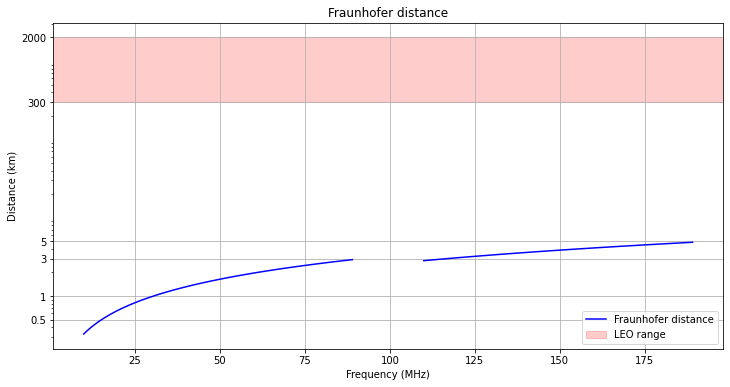

All LEO satellites are in far-field region at any frequency


In [3]:
import matplotlib.pyplot as plt
from astropy.constants import c
import numpy as np

c = c.value #m/s
D_hba = 62 #meters
D_lba = 70 #meters

freq_l = np.arange(10, 90, 1) 
freq_h = np.arange(110, 190, 1)

wvlength_l = c / (freq_l * 1e6)
wvlength_h = c / (freq_h * 1e6)

d_fraunhofer_l = ((2 * D_lba**2) / wvlength_l) 
d_fraunhofer_h = ((2 * D_hba**2) / wvlength_h) 

d_fraunhofer_l_km = d_fraunhofer_l/1000
d_fraunhofer_h_km = d_fraunhofer_h/1000



plt.figure(figsize=(12,6))
plt.plot(freq_l, d_fraunhofer_l_km, color='blue', label='Fraunhofer distance')
plt.plot(freq_h, d_fraunhofer_h_km, color='blue')
plt.axhspan(300, 2000, color='red', alpha=0.2, label='LEO range')

plt.xlabel('Frequency (MHz)')
plt.ylabel('Distance (km)')
plt.title('Fraunhofer distance')
plt.yscale('log')
plt.yticks([2000,300,5,3,1,0.5],[2000,300,5,3,1,0.5])

plt.grid()
plt.legend()
plt.show()
print('All LEO satellites are in far-field region at any frequency')

# Flux density plot

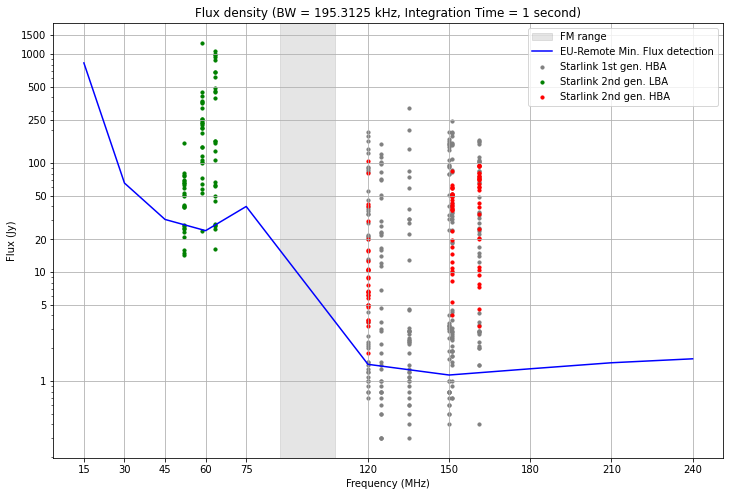

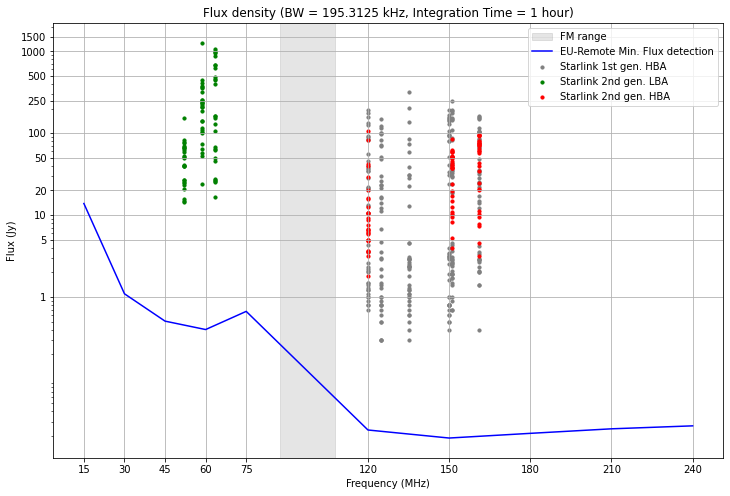

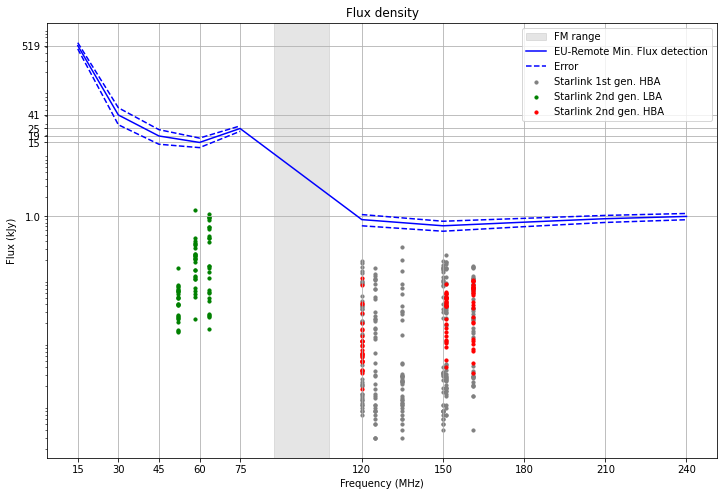

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# LOFAR cookbook data
f = [15, 30, 45, 60, 75, 120, 150, 180, 210, 240]
f_hba = [120, 150, 180, 210, 240]
f_lba = [15, 30, 45, 60, 75]

#200/1024 freq resolution, 1 sec time resolution
clock_freq = 200e6 # 200 MHz sample clock frequency
sample_nb = 1024 # number of samples
sb_bw = clock_freq / sample_nb # 195.3125 kHz bandwidth
int_time1s = 1 # integration time
int_time1h = 60*60

eu_janskys = np.array([519000, 41000, 19000, 15000, 25000, 890, 710, 810, 920, 1000])
#eu_janskys_extra = np.array([519000, 41000, 19000, 15000, 25000, 357.13, 313.88, 378.22, 441.48, 482.12])
eu_janskys_hba = np.array([890, 710, 810, 920, 1000])
# with double dipoles:
#eu_janskys_hba_extra_dipoles = np.array([357.13, 313.88, 378.22, 441.48, 482.12])

eu_janskys_lba = np.array([519000, 41000, 19000, 15000, 25000])
eu_janskys_bw1 = eu_janskys / np.sqrt(2 * sb_bw * int_time1s) 
eu_janskys_bw2 = eu_janskys / np.sqrt(2 * sb_bw * int_time1h) 

# Starlink Data
f_starlink_lba = [52]*26 + [58.5]*27 + [63.5]*27

# this flux is the actual physical signal that reaches the antenna so remains constant
flux_starlink2_lba = [
    # 50-54 MHz
    25.5, 24.6, 39.4, 41.1, 20.9, 14.4, 15.9, 70.3, 27.1, 23.5, 39.5, 53.1, 26.5, 15.0, 40.0, 50.2, 59.4, 151.5, 65.2, 65.9, 50.7, 67.9, 75.5, 77.3, 62.5, 81.8,
    # 56-61 MHz
    57.9, 235.8, 142.0, 361.8, 413.0, 140.9, 102.7, 73.0, 209.1, 52.7, 64.7, 99.7, 115.0, 107.9, 23.8, 255.8, 319.8, 221.7, 1273.6, 255.5, 354.8, 189.2, 210.9, 447.3, 235.1, 375.3, 242.4,
    # 61-66 MHz
    26.8, 25.1, 61.7, 67.6, 45.1, 50.0, 16.4, 27.8, 160.4, 63.5, 106.2, 153.5, 160.7, 128.5, 26.2, 686.8, 445.8, 996.7, 990.3, 620.5, 887.4, 458.5, 941.7, 1074.8, 399.1, 680.8, 486.1
]

f_starlink1_hba = [
    120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 120, 125, 
    135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 
    151, 161, 120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 
    120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 120, 125, 
    135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 
    151, 161, 120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 
    120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 120, 125, 
    135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 
    151, 161, 120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 
    120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 120, 125, 
    135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 
    151, 161, 120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 
    120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 120, 125, 135, 150, 151, 161, 120, 125
]

flux_starlink1_hba = [
    0.7, 0.9, 2.9, 167.3, 34.7, 14.9, 0.9, 3.0, 200.7, 30.8, 10.1, 2.9, 2.3, 2.9, 1.3, 3.3, 244.4, 48.7, 
    22.1, 1.0, 0.6, 2.9, 191.6, 17.0, 12.8, 0.5, 0.4, 3.2, 178.4, 31.6, 20.0, 1.3, 0.7, 2.5, 153.9, 25.2, 
    10.5, 0.8, 2.9, 192.2, 18.9, 23.8, 1.2, 0.8, 2.7, 139.2, 0.9, 0.4, 1.3, 0.7, 3.1, 159.1, 35.9, 12.3, 
    2.0, 0.6, 2.5, 79.2, 0.7, 2.7, 192.3, 23.0, 1.1, 0.6, 0.7, 2.8, 134.4, 21.7, 1.2, 3.1, 187.0, 24.6, 
    1.1, 0.3, 2.9, 131.1, 24.2, 3.3, 178.7, 23.1, 2.4, 91.9, 4.5, 150.2, 21.2, 1.5, 4.6, 149.2, 86.2, 1.4, 
    0.8, 4.7, 135.1, 40.6, 1.9, 4.2, 125.0, 29.7, 1.1, 4.0, 146.0, 22.2, 1.4, 0.3, 2.3, 107.7, 32.5, 3.5, 
    158.9, 26.2, 1.2, 0.5, 2.8, 163.7, 21.4, 13.9, 1.0, 0.6, 4.3, 158.2, 13.3, 1.0, 0.3, 3.2, 148.7, 28.5, 
    0.8, 3.5, 321.6, 33.3, 2.9, 2.9, 89.8, 16.8, 2.9, 154.1, 18.6, 14.0, 1.0, 0.3, 4.5, 145.2, 28.8, 2.0, 
    4.3, 150.6, 22.5, 1.9, 3.6, 102.2, 2.2, 100.2, 38.3, 0.8, 2.4, 67.4, 34.1, 0.8, 1.8, 1.6, 83.6, 34.5, 
    3.5, 83.6, 30.9, 1.0, 1.4, 2.3, 83.5, 51.5, 0.6, 3.0, 43.4, 33.7, 1.0, 1.8, 2.4, 80.0, 30.4, 2.0, 86.1, 
    48.2, 0.8, 0.4, 3.1, 84.5, 55.2, 1.4, 2.2, 94.8, 51.6, 2.1, 45.8, 2.2, 73.8, 51.5, 2.1, 102.3, 37.8, 
    6.8, 1.0, 3.4, 109.4, 84.8, 2.6, 70.9, 58.6, 0.5, 2.6, 35.6, 1.5, 101.5, 30.8, 0.8, 1.5, 104.7, 34.3, 
    12.1, 0.5, 1.0, 2.7, 114.6, 39.7, 16.1, 0.9, 0.8, 1.7, 66.2, 2.1, 122.2, 28.1, 24.1, 1.0, 2.8, 92.7, 
    70.2, 13.0, 0.8, 2.5, 75.3, 1.2, 98.7, 85.0, 0.8, 1.9, 106.9, 28.1, 0.5, 2.3, 96.1, 1.7, 155.0, 36.1, 
    11.3, 1.4, 0.7, 1.9, 1.4, 1.5, 114.8
]


f_starlink2_hba = [120, 151, 161] * 30

flux_starlink2_hba = [
    12.6, 10.8, 10.4, 16.0, 9.6, 20.2, 10.6, 12.4, 24.8, 3.6, 59.4, 76.9, 6.2, 60.7, 
    93.4, 3.2, 23.8, 39.7, 3.5, 37.9, 34.4, 3.6, 49.3, 43.0, 1.8, 52.3, 60.1, 6.7, 
    37.1, 57.1, 6.6, 41.3, 60.7, 4.8, 40.6, 80.7, 5.0, 62.6, 64.9, 105.6, 37.5, 96.0, 
    9.1, 4.0, 4.6, 6.1, 39.0, 69.7, 10.5, 45.7, 72.8, 7.6, 50.8, 76.9, 5.8, 50.7, 
    80.8, 6.5, 59.5, 93.8, 5.0, 51.7, 70.8, 8.8, 17.1, 20.7, 5.0, 49.6, 93.8, 20.2, 
    10.3, 7.8, 40.0, 14.8, 9.5, 42.5, 19.5, 11.2, 15.7, 84.9, 0, 29.2, 5.3, 3.2, 81.4, 
    8.3, 7.3, 10.5, 43.5, 71.5
]


plt.figure(figsize=(12,8))
plt.axvspan(87.5, 108, color='gray', alpha=0.2, label='FM range')
plt.plot(f, eu_janskys_bw1, color='blue', label='EU-Remote Min. Flux detection')
plt.scatter(f_starlink1_hba, flux_starlink1_hba, color='gray', s=10, label='Starlink 1st gen. HBA')
plt.scatter(f_starlink_lba, flux_starlink2_lba, color='green', s=10, label='Starlink 2nd gen. LBA')
plt.scatter(f_starlink2_hba, flux_starlink2_hba, color='red', s=10, label='Starlink 2nd gen. HBA')

plt.xlabel('Frequency (MHz)')
plt.xticks(f, f)
plt.ylabel('Flux (Jy)')
plt.yscale('log')
#plt.yticks([519000, 41000, 19000, 15000, 25000, 1000], [519, 41, 19, 15, 25, 1.0]) # BW=1Hz
plt.yticks([1500, 1000, 500, 250, 100, 50, 20, 10, 5, 1], [1500, 1000, 500, 250, 100, 50, 20, 10, 5, 1]) # # BW=195.3125 kHz
plt.title('Flux density (BW = 195.3125 kHz, Integration Time = 1 second)')
#plt.title('Flux density')

plt.grid()
plt.legend()
plt.show()


##################################################################
# in the article it says that the observation for the satellites was for 1h so idk if i should put 1h integration time
plt.figure(figsize=(12,8))
plt.axvspan(87.5, 108, color='gray', alpha=0.2, label='FM range')
plt.plot(f, eu_janskys_bw2, color='blue', label='EU-Remote Min. Flux detection')
plt.scatter(f_starlink1_hba, flux_starlink1_hba, color='gray', s=10, label='Starlink 1st gen. HBA')
plt.scatter(f_starlink_lba, flux_starlink2_lba, color='green', s=10, label='Starlink 2nd gen. LBA')
plt.scatter(f_starlink2_hba, flux_starlink2_hba, color='red', s=10, label='Starlink 2nd gen. HBA')

plt.xlabel('Frequency (MHz)')
plt.xticks(f, f)
plt.ylabel('Flux (Jy)')
plt.yscale('log')
plt.yticks([1500, 1000, 500, 250, 100, 50, 20, 10, 5, 1], [1500, 1000, 500, 250, 100, 50, 20, 10, 5, 1]) # # BW=195.3125 kHz
plt.title('Flux density (BW = 195.3125 kHz, Integration Time = 1 hour)')

plt.grid()
plt.legend()
plt.show()

###################################
plt.figure(figsize=(12,8))
plt.axvspan(87.5, 108, color='gray', alpha=0.2, label='FM range')
plt.plot(f, eu_janskys, color='blue', label='EU-Remote Min. Flux detection')
#plt.plot(f, eu_janskys_extra, color='blue', label='EU-Remote Min. Flux detection')

######## with double number of antennas it could be possible to detect (192 hba)
#plt.plot(f_hba, eu_janskys_hba_extra_dipoles+error_SEFD_h, 'b--', label='Error')
#plt.plot(f_hba, eu_janskys_hba_extra_dipoles-error_SEFD_h, 'b--')
plt.plot(f_hba, eu_janskys_hba+error_SEFD_h, 'b--', label='Error')
plt.plot(f_hba, eu_janskys_hba-error_SEFD_h, 'b--')
plt.plot(f_lba, eu_janskys_lba+error_SEFD_l, 'b--')
plt.plot(f_lba, eu_janskys_lba-error_SEFD_l, 'b--')

plt.scatter(f_starlink1_hba, flux_starlink1_hba, color='gray', s=10, label='Starlink 1st gen. HBA')
plt.scatter(f_starlink_lba, flux_starlink2_lba, color='green', s=10, label='Starlink 2nd gen. LBA')
plt.scatter(f_starlink2_hba, flux_starlink2_hba, color='red', s=10, label='Starlink 2nd gen. HBA')

plt.xlabel('Frequency (MHz)')
plt.xticks(f, f)
plt.ylabel('Flux (kJy)')
plt.yscale('log')
plt.yticks([519000, 41000, 19000, 15000, 25000, 1000], [519, 41, 19, 15, 25, 1.0]) # BW=1Hz 100, 50, 20, 10, 5, 1], [1500, 1000, 500, 250, 100, 50, 20, 10, 5, 1]) # # BW=195.3125 kHz
plt.title('Flux density')

plt.grid()
plt.legend()
plt.show()

In [5]:
#nunfar 1000jy at 50mhz nenufar sens, 19000jy 45mhz could use 19 cte change. (nenufar library)
#for single station freq and time integration is fixed: 1s
#can record antenna info individually with high resolution and compute vis yourself but very computed: aartfac